In [32]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import os
import zipfile

In [33]:
root_path = "/home/stefan/ioai-prep/kits/emoji/"

sample_img_path = f"{root_path}/emoji_dataset/train/train_542.png"

# Data

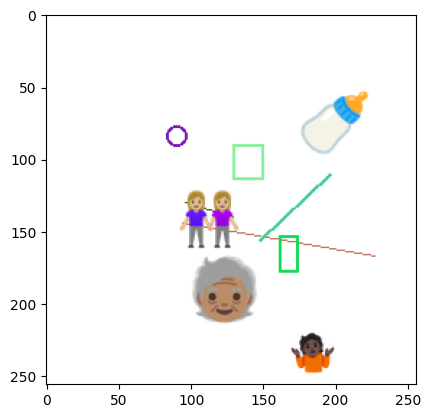

In [34]:
img = Image.open(sample_img_path).convert("RGB")
img = np.array(img)
plt.imshow(img)

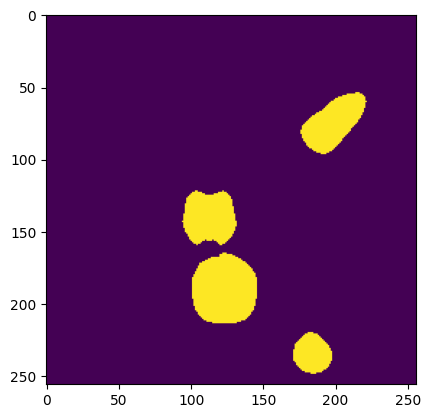

In [35]:
def get_mask(img: np.array) -> np.array:
    grayscale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.medianBlur(grayscale, 13)

    _, threshold = cv2.threshold(blur, 254.9, 256, cv2.THRESH_BINARY_INV)
    return threshold  # .shape = (256, 256)

plt.imshow(get_mask(img))

# Submission

In [36]:
test_csv_path = f"{root_path}/test.csv"
test_df = pd.read_csv(test_csv_path)

In [37]:
predictions = []

os.makedirs(f"{root_path}/sub/predictions", exist_ok=True)

for idx, row in tqdm(
    test_df.iterrows(), total=len(test_df), desc="Processing test set"
):
    sample_id = row["SampleID"]
    img_path = f"{root_path}/{row['Path']}"

    img = Image.open(img_path).convert("RGB")
    img = np.array(img)

    mask = get_mask(img)
    cv2.imwrite(f"{root_path}/sub/predictions/{sample_id}.png", mask)

    predictions.append(
        {"SampleID": sample_id, "PredictedMask": f"predictions/{sample_id}.png"}
    )

submission_df = pd.DataFrame(predictions)
submission_path = f"{root_path}/sub/submission.csv"
submission_df.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")
print(submission_df.head())


with zipfile.ZipFile(f"{root_path}/sub.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(f"{root_path}/sub"):
        for f in files:
            z.write(os.path.join(root, f), os.path.relpath(os.path.join(root, f), f"{root_path}/sub"))

Processing test set: 100%|██████████| 500/500 [00:02<00:00, 224.69it/s]


Submission saved to /home/stefan/ioai-prep/kits/emoji//sub/submission.csv
    SampleID              PredictedMask
0  test_1500  predictions/test_1500.png
1  test_1501  predictions/test_1501.png
2  test_1502  predictions/test_1502.png
3  test_1503  predictions/test_1503.png
4  test_1504  predictions/test_1504.png


In [38]:
submission_df = pd.DataFrame(predictions)
submission_path = f"{root_path}/sub/submission.csv"
submission_df.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")
print(submission_df.head())

Submission saved to /home/stefan/ioai-prep/kits/emoji//sub/submission.csv
    SampleID              PredictedMask
0  test_1500  predictions/test_1500.png
1  test_1501  predictions/test_1501.png
2  test_1502  predictions/test_1502.png
3  test_1503  predictions/test_1503.png
4  test_1504  predictions/test_1504.png
